In [1]:

!pip install mediapipe==0.10.20

# 2. Hard Reset the internal cache
import sys
if 'mediapipe' in sys.modules:
    del sys.modules['mediapipe']

# 3. Use the DIRECT import path (This avoids the .solutions error)
try:
    import mediapipe as mp
    from mediapipe.python.solutions import hands as mp_hands
    from mediapipe.python.solutions import drawing_utils as mp_drawing

    # Test it immediately
    test_hands = mp_hands.Hands()
    print("✅ SUCCESS! MediaPipe is now working correctly.")
except Exception as e:
    print(f" Still an error: {e}")
    print("\nPRO TIP: If this failed, go to the top menu: 'Runtime' -> 'Restart Session', then run ONLY this cell.")

✅ SUCCESS! MediaPipe is now working correctly.


In [2]:
!pip install opencv-python tensorflow gtts pandas scikit-learn --quiet

In [4]:


import mediapipe as mp
import cv2
import numpy as np
import pandas as pd
import os
import tensorflow as tf
from google.colab import drive
from google.colab import files
from gtts import gTTS
from IPython.display import Audio, display

# Direct import to avoid the "solutions" error
import mediapipe.python.solutions.hands as mp_hands
hands = mp_hands.Hands(static_image_mode=True, max_num_hands=1, min_detection_confidence=0.5)

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
YOUR_PATH = '/content/drive/MyDrive/Signlanguage project/ASL_Dataset'

data_list = []
print("Starting landmark extraction...")

for label in sorted(os.listdir(YOUR_PATH)):
    label_path = os.path.join(YOUR_PATH, label)
    if not os.path.isdir(label_path): continue

    print(f"Processing Letter: {label}")
    for img_name in os.listdir(label_path):
        img_path = os.path.join(label_path, img_name)
        img = cv2.imread(img_path)
        if img is None: continue

        # Extract Landmarks
        results = hands.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        if results.multi_hand_landmarks:
            lm_list = []
            for lm in results.multi_hand_landmarks[0].landmark:
                lm_list.extend([lm.x, lm.y, lm.z])
            lm_list.append(label)
            data_list.append(lm_list)

# Save to CSV
df = pd.DataFrame(data_list)
df.to_csv('asl_landmarks.csv', index=False)
print("Done! CSV created.")

Starting landmark extraction...
Processing Letter: A
Processing Letter: B
Processing Letter: C
Processing Letter: D
Processing Letter: E
Processing Letter: F
Processing Letter: G
Processing Letter: H
Processing Letter: I
Processing Letter: J
Processing Letter: K
Processing Letter: L
Processing Letter: M
Processing Letter: N
Processing Letter: O
Processing Letter: P
Processing Letter: Q
Processing Letter: R
Processing Letter: S
Processing Letter: T
Processing Letter: U
Processing Letter: V
Processing Letter: W
Processing Letter: X
Processing Letter: Y
Processing Letter: Z
Done! CSV created.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df.to_csv('/content/drive/MyDrive/asl_landmarks.csv', index=False)
print("Saved successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved successfully!


In [5]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/asl_landmarks.csv')
print("CSV loaded successfully!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
CSV loaded successfully!


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

file_path = '/content/drive/MyDrive/asl_landmarks.csv'
df = pd.read_csv(file_path)
X = df.iloc[:, :-1].values.astype('float32')
y = df.iloc[:, -1].values

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
y_categorical = tf.keras.utils.to_categorical(y_encoded)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.1)

model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(63,)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(len(encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, verbose=0)
print("Model trained on landmarks successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model trained on landmarks successfully!


Saving b.jpg to b.jpg

Processing: b.jpg


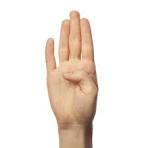

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
Predicted Letter: B
TEXT: The letter is B


In [7]:
from IPython.display import display, Audio, Image
import cv2
import numpy as np
from gtts import gTTS

def speak_result(text):
    if not text: return
    print(f"TEXT: {text}")
    tts = gTTS(text)
    tts.save('res.mp3')
    display(Audio('res.mp3', autoplay=True))


def run_final_test():
    uploaded = files.upload()

    for filename in uploaded.keys():

        # SHOW IMAGE/VIDEO NAME
        print(f"\nProcessing: {filename}")

        if filename.lower().endswith(('.mp4', '.mov')):
            #  VIDEO MODE
            cap = cv2.VideoCapture(filename)
            word = ""
            prev_char = ""
            stable_count = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                res = hands.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

                if res.multi_hand_landmarks:
                    lms = []
                    for lm in res.multi_hand_landmarks[0].landmark:
                        lms.extend([lm.x, lm.y, lm.z])

                    pred = model.predict(np.array([lms]), verbose=0)

                    if np.max(pred) > 0.8:
                        char = encoder.inverse_transform([np.argmax(pred)])[0]

                        if char == prev_char:
                            stable_count += 1
                        else:
                            stable_count = 0
                            prev_char = char

                        if stable_count == 10:
                            if not word.endswith(char):
                                word += char

            cap.release()
            speak_result(f"The video shows {word}")

        else:
            #  IMAGE MODE
            img = cv2.imread(filename)

            #  DISPLAY IMAGE
            display(Image(filename=filename))

            res = hands.process(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

            if res.multi_hand_landmarks:
                lms = []
                for lm in res.multi_hand_landmarks[0].landmark:
                    lms.extend([lm.x, lm.y, lm.z])

                pred = model.predict(np.array([lms]))
                char = encoder.inverse_transform([np.argmax(pred)])[0]

                #  SHOW RESULT
                print(f"Predicted Letter: {char}")

                speak_result(f"The letter is {char}")
            else:
                print("No hand detected. Make sure the hand is clearly visible.")


run_final_test()